# Llama-3.2-1B × OpenMathInstruct-2 leaderboard — robustness (9000 steps)

Cross-**model** *and* cross-**dataset** robustness in one cell: does `adam-polar-product-lora-coupled-spectral-chord-tight` (ns=8, full Newton–Schulz whitening, picard=1) keep its eval-loss edge over AdamW-LoRA when the base is **Llama-3.2-1B** (not OLMo) *and* the task is **math-IFT** (OpenMathInstruct-2, not code)?

Setup: Llama-3.2-1B × OpenMathInstruct-2 `train_2M` (Llama-tokenized cache `data/openmath_instruct_2_2m_packed_seq2048_llama32`, 512,440 packed slots @ seq=2048) × global_batch=16 (4×4) × packed_v1.1 × constant LR × α=r × all-linear × bf16 × compile × single-GPU Blackwell. `max_steps=9000`, `eval_every=250`.

- **AdamW**: η ∈ {3e-5, 1e-4, 3e-4, 1e-3}
- **chord-tight ns=8** (`adam-polar-product-lora-coupled-spectral-chord-tight`, `--muon_ns_steps 8 --polar_method ns`, picard=1): η ∈ {3e-3, 1e-2, 3e-2, 1e-1} — grid pre-extended to 1e-1 because OLMo×math's ns=8 pinned at the 1e-2 grid edge.

Source log groups: `adamw_robustness_llama32_1b_openmath_r{64,256}_blackwell` and `chord_tight_robustness_llama32_1b_openmath_r{64,256}_ns8_blackwell`. No ns=5 arm here (OLMo×math established ns=8 ≈ ns=5; this notebook goes straight to ns=8). Grids are single-sweep — no separate `_ext_right` groups.

**σ anchor**: no per-(model,dataset) multi-seed AdamW run. Δ quoted against `σ_AdamW(packed_v1, opc-sft-stage2, r=64) = 0.0017` as a **loose proxy only** — now cross-model *and* cross-dataset, so treat σ-units as indicative, not rigorous, until re-anchored.

In [4]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import matplotlib.pyplot as plt

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from lora_playground.loader import load_runs
from lora_playground.plotting import compare_variants_figure
from lora_playground.plotting.colors import OPTIM_COLORS, OPTIM_MARKERS

OPT_ADAMW = 'adamw'
OPT_CT    = 'adam-polar-product-lora-coupled-spectral-chord-tight'  # ns=8 throughout this nb

def variant_key(cfg):
    opt = cfg.get('optimizer')
    if opt == OPT_ADAMW: return 'AdamW'
    if opt == OPT_CT:    return 'chord-tight ns=8'
    return None

VARIANT_COLORS  = {'AdamW': OPTIM_COLORS.get(OPT_ADAMW, 'black'),
                   'chord-tight ns=8': OPTIM_COLORS.get(OPT_CT, 'tab:red')}
VARIANT_MARKERS = {'AdamW': OPTIM_MARKERS.get(OPT_ADAMW, 'o'),
                   'chord-tight ns=8': OPTIM_MARKERS.get(OPT_CT, 's')}

def render_cell(groups, rank, suptitle, final_ylim=None, traj_ylim=None):
    runs = load_runs(where={'log_group': groups}, logs_root='../logs',
                     warn_cross_commit=False, quiet=True)
    dedup = {}
    for cfg, hist in runs:
        k = (cfg['optimizer'], float(cfg['lr']))
        if k not in dedup or len(hist) > len(dedup[k][1]):
            dedup[k] = (cfg, hist)
    fig, table_df, summary_df = compare_variants_figure(
        variants={'AdamW': {'optimizer': OPT_ADAMW},
                  'chord-tight ns=8': {'optimizer': OPT_CT}},
        common_where={'lora_r': rank}, ref_label='AdamW', sigma_ref=0.0017,
        max_steps=9000, allow_partial=True,
        prefetched_runs=list(dedup.values()), variant_key=variant_key,
        colors=VARIANT_COLORS, markers=VARIANT_MARKERS,
        suptitle=suptitle, figsize=(11, 4),
        final_ylim=final_ylim, traj_ylim=traj_ylim,
    )
    plt.show()
    print(f'--- {suptitle} per-η table ---')
    display(table_df.style.format('{:.4f}', na_rep='—'))
    print(f'--- {suptitle} summary ---')
    display(summary_df.style.format({
        'best_lr': '{:.1e}', 'final': '{:.4f}',
        'delta': '{:+.4f}', 'delta_sigma': '{:+.2f}σ'
    }, na_rep='—'))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## r=64

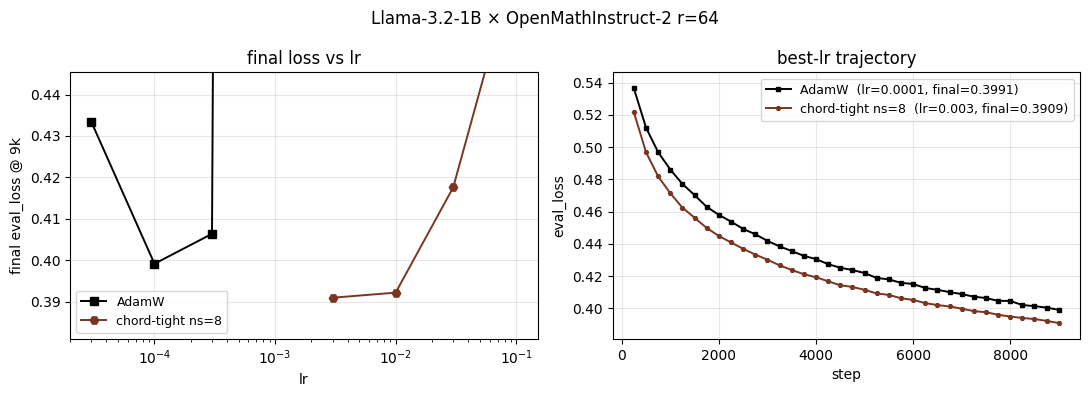

--- Llama-3.2-1B × OpenMathInstruct-2 r=64 per-η table ---


,AdamW,chord-tight ns=8
lr,,
0.000030,0.4334,—
0.000100,0.3991,—
0.000300,0.4064,—
0.001000,3.1639,—
0.003000,—,0.3909
0.010000,—,0.3922
0.030000,—,0.4176
0.100000,—,0.4728


--- Llama-3.2-1B × OpenMathInstruct-2 r=64 summary ---


,variant,best_lr,final,delta,delta_sigma
0,AdamW,1.0e-04,0.3991,—,—
1,chord-tight ns=8,3.0e-03,0.3909,-0.0082,-4.82σ


In [5]:
GROUPS_R64 = [
    'adamw_robustness_llama32_1b_openmath_r64_blackwell',
    'chord_tight_robustness_llama32_1b_openmath_r64_ns8_blackwell',
    'chord_tight_robustness_llama32_1b_openmath_r64_ns8_ext_left_blackwell',  # down-ext {1e-3, 3e-4}: ns=8 best pinned at grid-min 3e-3
]
# ylim left auto until data lands; tune after first full evals (see OLMo nb caps)
render_cell(GROUPS_R64, 64, 'Llama-3.2-1B × OpenMathInstruct-2 r=64')

## r=256

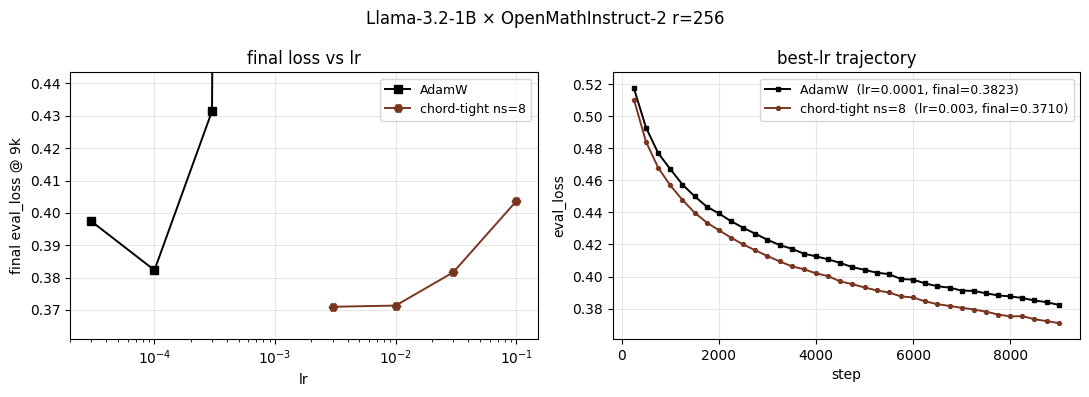

--- Llama-3.2-1B × OpenMathInstruct-2 r=256 per-η table ---


,AdamW,chord-tight ns=8
lr,,
0.000030,0.3974,—
0.000100,0.3823,—
0.000300,0.4314,—
0.001000,3.6186,—
0.003000,—,0.3710
0.010000,—,0.3714
0.030000,—,0.3816
0.100000,—,0.4036


--- Llama-3.2-1B × OpenMathInstruct-2 r=256 summary ---


,variant,best_lr,final,delta,delta_sigma
0,AdamW,1.0e-04,0.3823,—,—
1,chord-tight ns=8,3.0e-03,0.3710,-0.0113,-6.65σ


In [6]:
GROUPS_R256 = [
    'adamw_robustness_llama32_1b_openmath_r256_blackwell',
    'chord_tight_robustness_llama32_1b_openmath_r256_ns8_blackwell',
    'chord_tight_robustness_llama32_1b_openmath_r256_ns8_ext_left_blackwell',  # down-ext {1e-3, 3e-4}: ns=8 best pinned at grid-min 3e-3
]
render_cell(GROUPS_R256, 256, 'Llama-3.2-1B × OpenMathInstruct-2 r=256')